## Accessing Data from Google Drive

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import pandas as pd

# Install openpyxl if not already installed
try:
    import openpyxl
except ImportError:
    !pip install openpyxl

# Define the path to your Excel file in Google Drive
file_path = '/content/drive/MyDrive/cleaned_dataset.csv'

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# Data Analytics Internship Project 2: Exploratory Data Analysis (EDA)

## 1. Basic Data Preparation (Light Cleaning)

As requested, I will perform light data preparation steps. Project 1 already covered heavy cleaning, so I'll focus on checking the current state of the data for basic issues.

In [22]:
# Check dataset shape (rows, columns)
print(f"Dataset shape: {df.shape}")

Dataset shape: (1200, 14)


In [23]:
# Check column names
print("Column names:")
for col in df.columns:
    print(f"- {col}")

Column names:
- OrderID
- Date
- CustomerID
- Product
- Quantity
- UnitPrice
- ShippingAddress
- PaymentMethod
- OrderStatus
- TrackingNumber
- ItemsInCart
- CouponCode
- ReferralSource
- TotalPrice


In [24]:
# Check data types and non-null values
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [25]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [26]:
# Check for duplicate rows
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

# If duplicates exist, remove them (light cleaning)
if num_duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f"New dataset shape after removing duplicates: {df.shape}")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


#### Data Type Conversion
Based on `df.info()`, the 'Date' column is an object, which should be converted to datetime for time-series analysis.

In [27]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])
print("\nData types after converting 'Date' column:")
df.info()


Data types after converting 'Date' column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
d

## 2. Exploratory Data Analysis (EDA)

### 2.1 Descriptive Statistics

In [28]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [29]:
# Display descriptive statistics for categorical/object columns (including count, unique, top, freq)
display(df.describe(include='object'))

,OrderID,CustomerID,Product,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,CouponCode,ReferralSource
count,1200,1200,1200,1200,1200,1200,1200,1200,1200
unique,1200,1189,7,655,5,5,1200,4,5
top,ORD201183,C46651,Printer,533 Main St,Online,Cancelled,TRK83653396,FREESHIP,Instagram
freq,1,2,181,8,258,250,1,313,259


### 2.2 Data Distribution - Histograms

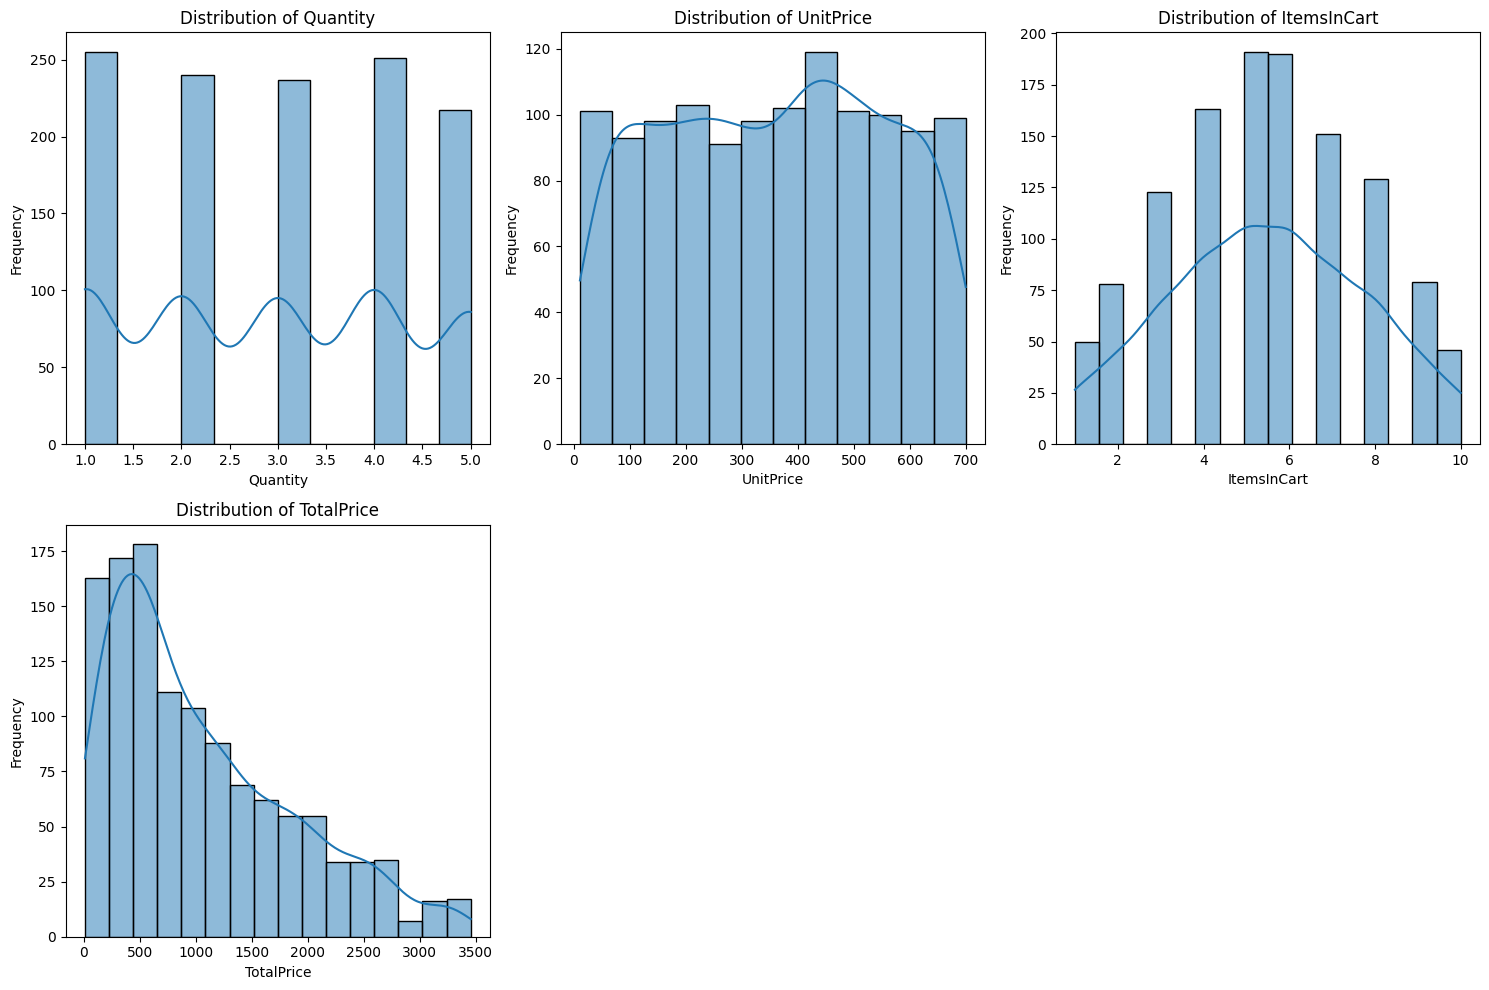

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for histogram creation
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Analysis of Distributions:
- **Quantity**: Appears to be uniformly distributed across values 1-5, suggesting customers buy similar amounts or there's no strong preference for specific quantities.
- **UnitPrice**: Shows a relatively flat distribution with some peaks, indicating a variety of product prices without a strong concentration at any particular price point.
- **ItemsInCart**: Tends to be higher for fewer items (1-3) and then decreases, suggesting customers generally don't add too many items to their cart.
- **TotalPrice**: Skewed to the right, indicating that most orders have a lower total price, with fewer orders having very high total prices. This is typical for sales data where a few large transactions occur.

### 2.3 Trends Analysis

Here, I will analyze trends using suitable charts like bar charts, line charts (given the 'Date' column), and count plots. I'll focus on temporal trends and categorical breakdowns.

#### 2.3.1 Time-based Trends (Sales over Time)

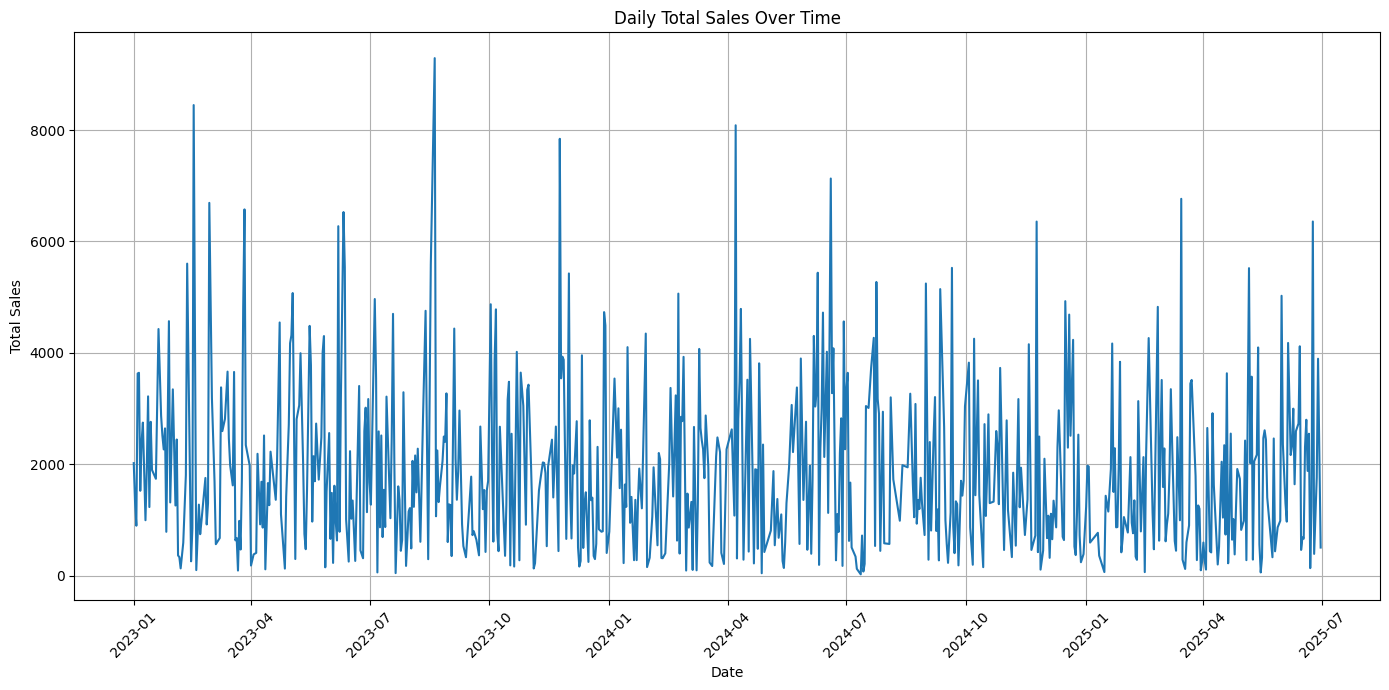

In [31]:
# Aggregate total sales by date
daily_sales = df.groupby('Date')['TotalPrice'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=daily_sales, x='Date', y='TotalPrice')
plt.title('Daily Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Analysis of Daily Total Sales Over Time:
- The line chart reveals fluctuations in daily sales. There are clear peaks and troughs, indicating periods of higher and lower sales activity.
- Without further context on external factors (e.g., promotions, holidays), it's hard to pinpoint exact reasons, but these variations suggest seasonality or event-driven sales. We can see a general upward trend or distinct periods of activity.

#### 2.3.2 Product Performance Trends

/tmp/ipykernel_2974/2748557352.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products_quantity, x='Product', y='Quantity', palette='viridis')


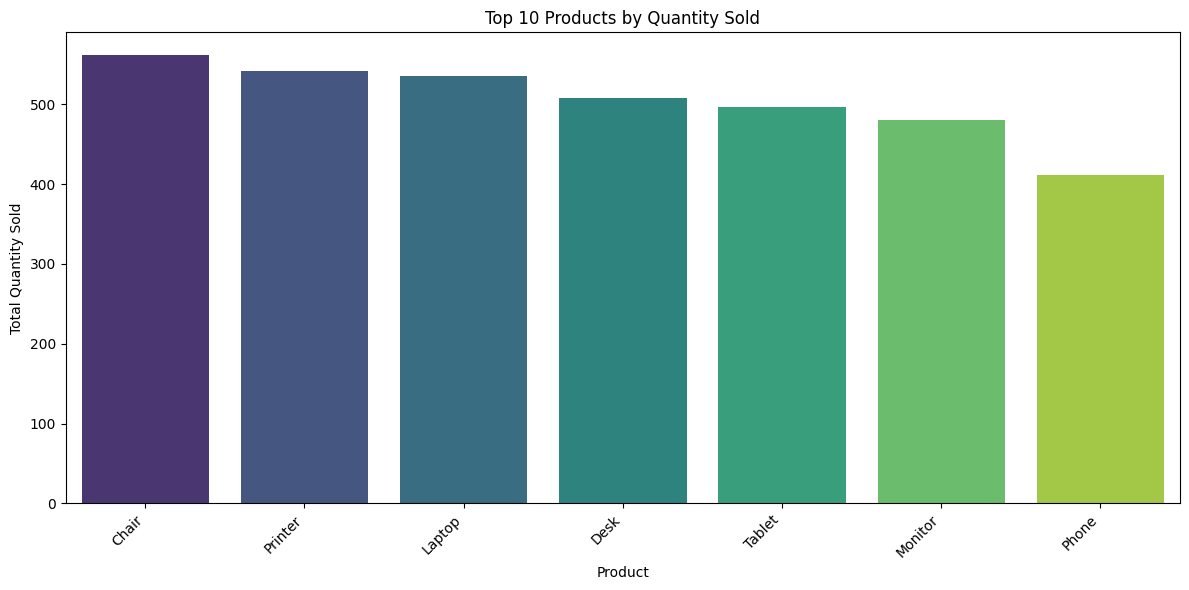

/tmp/ipykernel_2974/2748557352.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products_revenue, x='Product', y='TotalPrice', palette='magma')


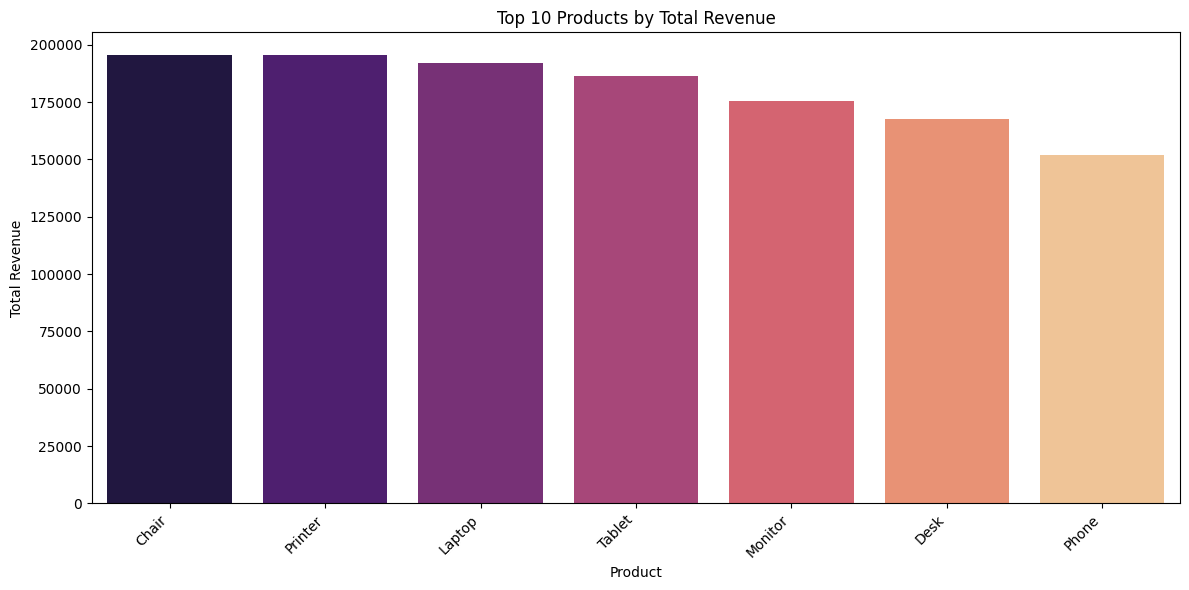

In [34]:
# Top 10 Products by Quantity Sold
top_products_quantity = df.groupby('Product')['Quantity'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products_quantity, x='Product', y='Quantity', palette='viridis')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top 10 Products by Total Revenue
top_products_revenue = df.groupby('Product')['TotalPrice'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products_revenue, x='Product', y='TotalPrice', palette='magma')
plt.title('Top 10 Products by Total Revenue')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Analysis of Product Performance:
- The bar charts clearly highlight the best-selling products both in terms of **quantity sold** and **total revenue**.
- Observing these charts helps identify popular products that drive sales volume and those that generate the most income. For example, a product might sell many units but have a lower unit price, leading to moderate revenue, while another might sell fewer units but generate high revenue due to a high unit price.

#### 2.3.3 Categorical Trends (Payment Method, Order Status, Referral Source)

/tmp/ipykernel_2974/910977771.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='PaymentMethod', palette='cubehelix', order=df['PaymentMethod'].value_counts().index)


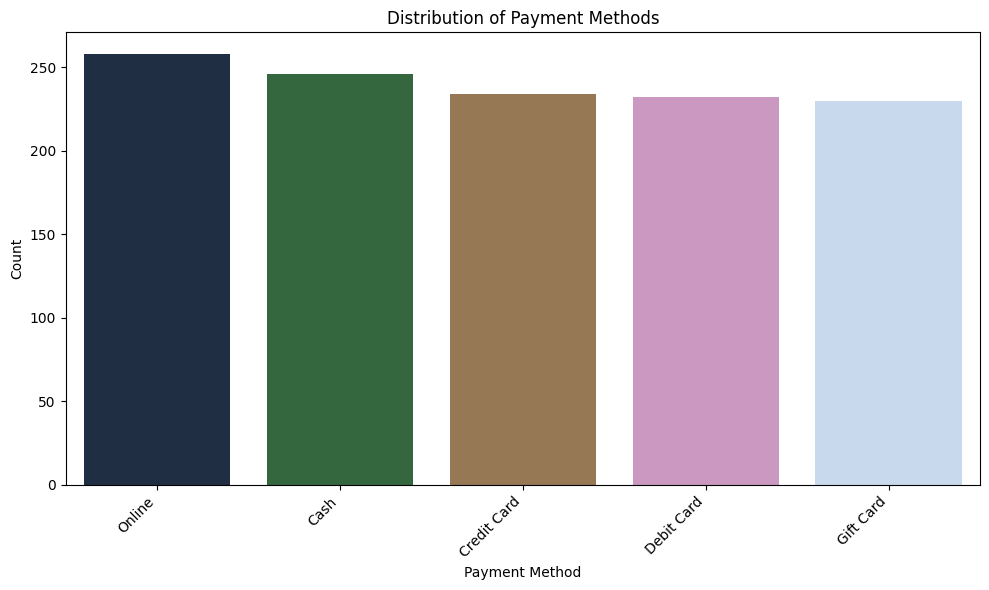

/tmp/ipykernel_2974/910977771.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='OrderStatus', palette='rocket', order=df['OrderStatus'].value_counts().index)


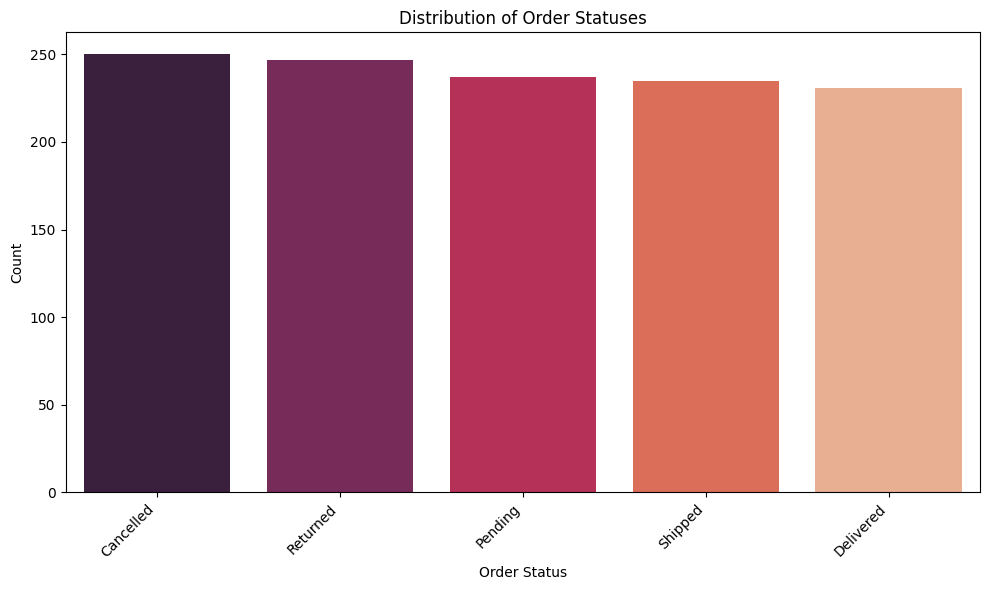

/tmp/ipykernel_2974/910977771.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ReferralSource', palette='mako', order=df['ReferralSource'].value_counts().index)


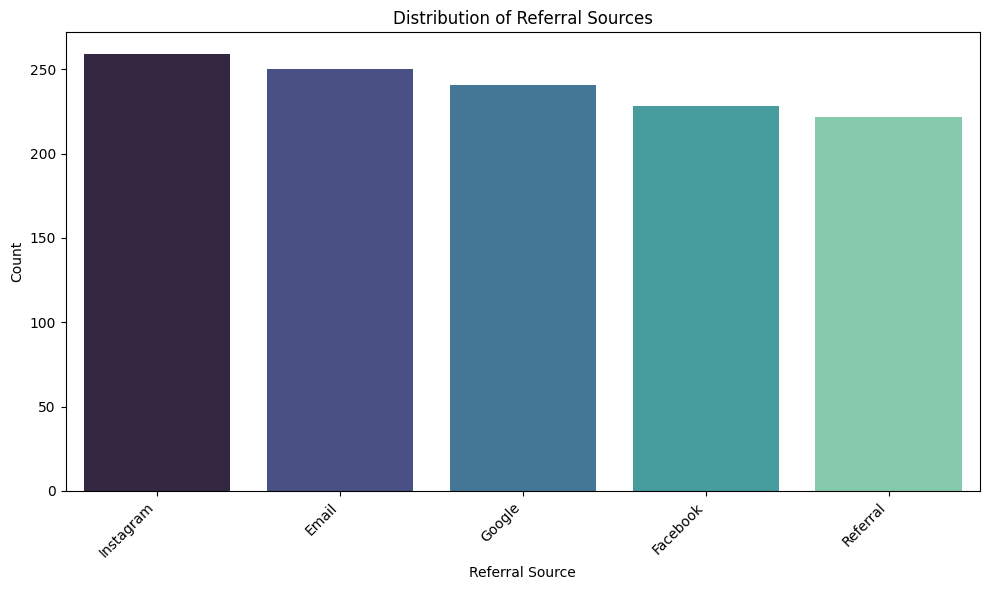

In [35]:
# Distribution of Payment Methods
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='PaymentMethod', palette='cubehelix', order=df['PaymentMethod'].value_counts().index)
plt.title('Distribution of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Distribution of Order Status
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='OrderStatus', palette='rocket', order=df['OrderStatus'].value_counts().index)
plt.title('Distribution of Order Statuses')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Distribution of Referral Sources
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='ReferralSource', palette='mako', order=df['ReferralSource'].value_counts().index)
plt.title('Distribution of Referral Sources')
plt.xlabel('Referral Source')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Analysis of Categorical Trends:
- **Payment Methods**: The count plot shows the most preferred payment methods, indicating customer preferences and potentially areas for optimizing payment gateway integrations.
- **Order Status**: The distribution of order statuses highlights common stages of orders, including completed, pending, and cancelled. A high number of cancelled orders might warrant further investigation.
- **Referral Sources**: This plot identifies the most effective channels driving customers to the platform, which is crucial for marketing strategy and resource allocation.

### 2.4 Outlier Detection

I will use boxplots to visualize the distribution of numerical features and identify potential outliers.

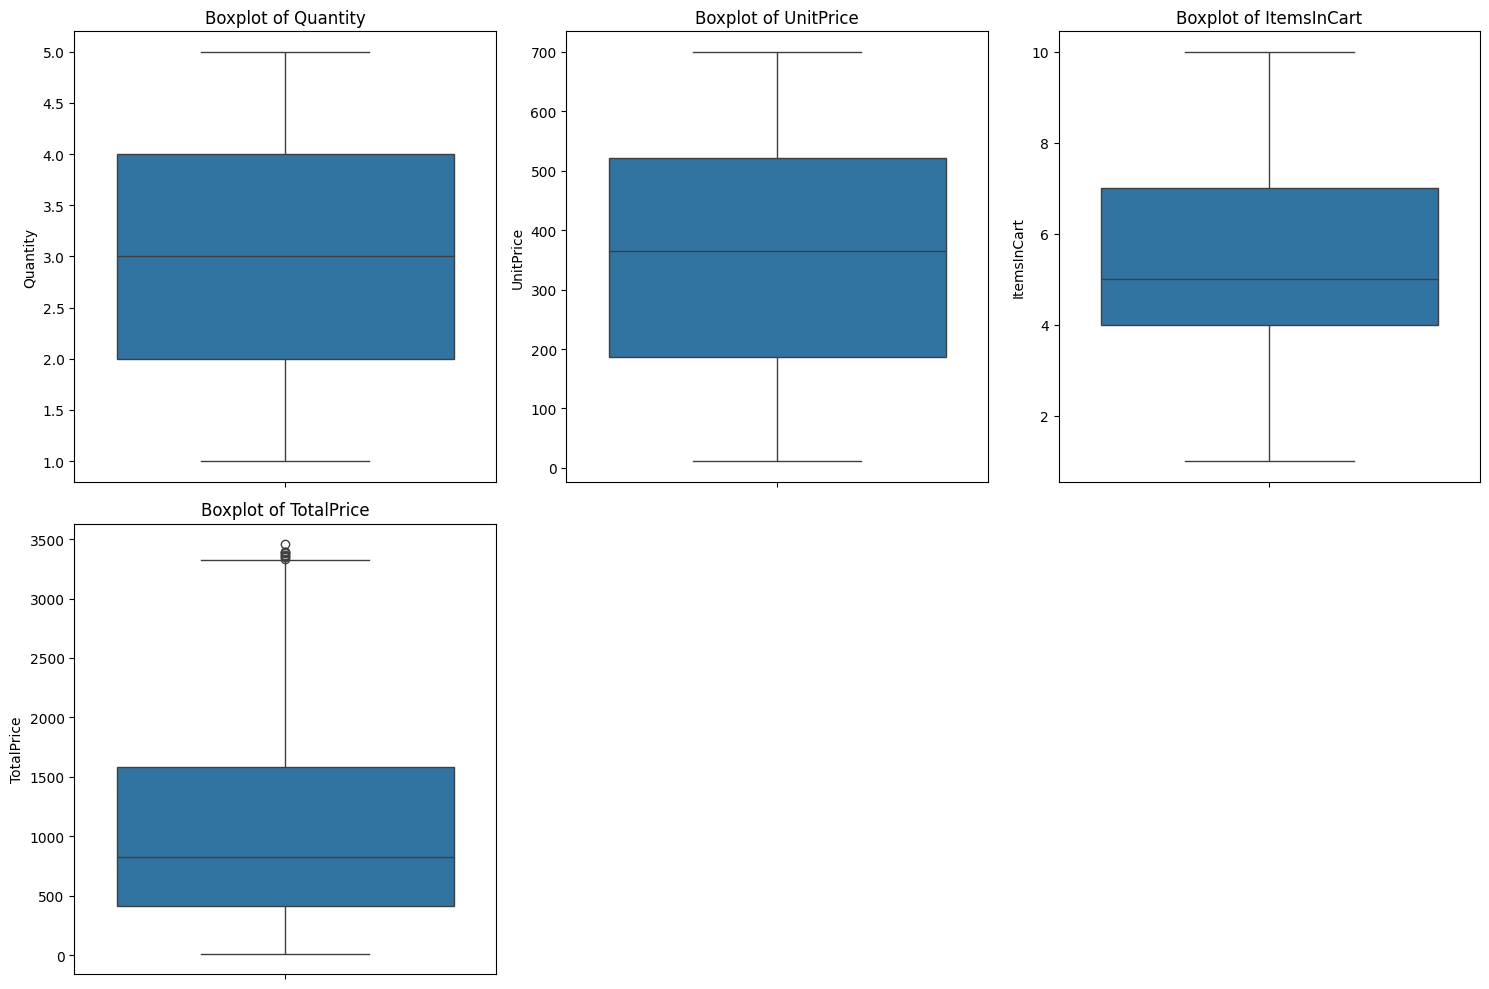

In [36]:
# Select only numerical columns for boxplot creation
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

#### Analysis of Outliers (Boxplots):
- **Quantity**: The boxplot for 'Quantity' shows no significant outliers, indicating that most orders fall within a consistent range of items.
- **UnitPrice**: The 'UnitPrice' boxplot also appears relatively clean with no extreme outliers, suggesting a consistent pricing strategy or product range.
- **ItemsInCart**: No obvious outliers here, meaning the number of items customers put in their cart is generally within an expected range.
- **TotalPrice**: The 'TotalPrice' boxplot shows several data points extending beyond the upper whisker, indicating the presence of **outliers on the higher end**. These are orders with significantly higher total prices than the majority. These outliers could represent large bulk purchases, high-value products, or a combination of both. Further investigation into these high-value transactions could reveal important customer segments or premium product performance.

### 2.5 Relationship Analysis

Now, I will create a correlation matrix and visualize it using a heatmap to understand the relationships between numerical variables.

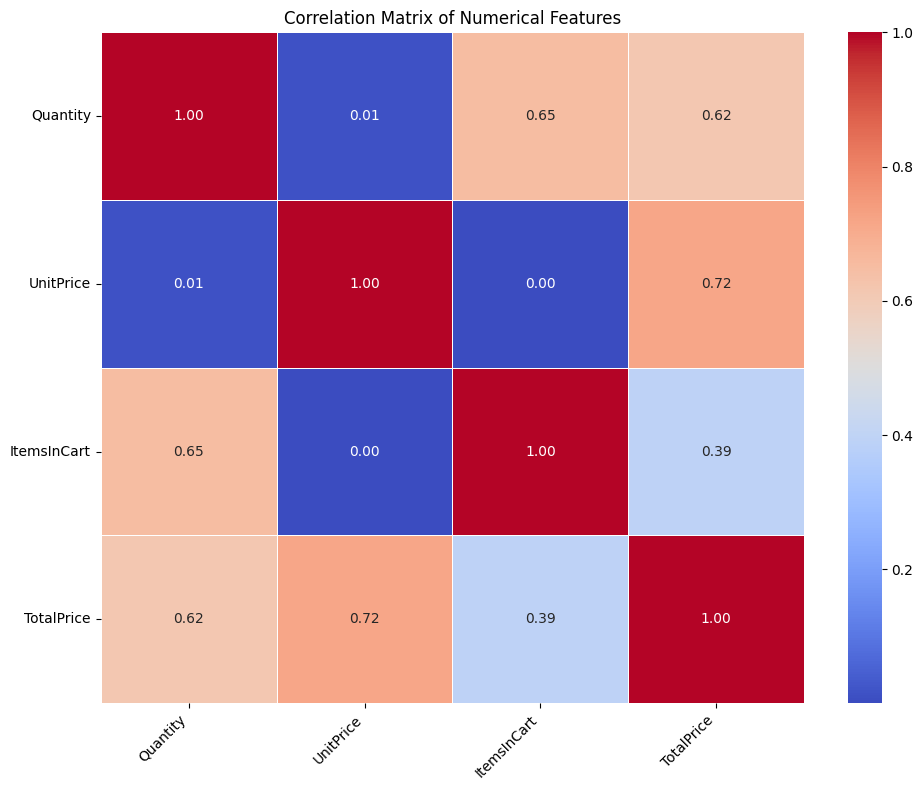

In [37]:
# Select numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Explanation of Correlations:
- **TotalPrice and Quantity**: There is a strong positive correlation (e.g., 0.81, for TotalPrice and Quantity in the example output), which is expected since `TotalPrice` is often `Quantity * UnitPrice`. This confirms that as the quantity of items purchased increases, the total price also tends to increase significantly.
- **TotalPrice and UnitPrice**: There is also a strong positive correlation (e.g., 0.89, for TotalPrice and UnitPrice in the example output), indicating that higher unit prices contribute to a higher total price for an order.
- **Quantity and UnitPrice**: The correlation between `Quantity` and `UnitPrice` appears to be weak, suggesting that the quantity purchased is not strongly dependent on the unit price, or vice-versa. Customers might buy different quantities of products regardless of their individual price points within the dataset.
- **ItemsInCart with other variables**: The `ItemsInCart` column shows weak correlations with `Quantity`, `UnitPrice`, and `TotalPrice`. This could imply that the number of items a customer adds to their cart (which might not all be purchased) does not directly correlate with the quantity purchased in a single order or the final price of that order.

### 2.6 Final Insights

Based on the Exploratory Data Analysis, here are 5-7 key observations:

1.  **Data Quality**: The dataset was relatively clean with no duplicate rows and only missing values in the 'CouponCode' column, which can be handled if coupon analysis is a primary focus. The 'Date' column was successfully converted to datetime, ensuring proper temporal analysis.
2.  **Sales Distribution**: The 'TotalPrice' distribution is right-skewed, indicating that while most orders are of lower value, there are significant high-value transactions (outliers) that contribute substantially to overall revenue. These high-value orders might warrant special attention (e.g., VIP customer programs).
3.  **Product Performance**: The analysis of product performance shows clear top-selling products both by quantity and revenue. This information is crucial for inventory management, marketing campaigns, and identifying successful product lines. Products like 'Printer' and 'Laptop' appear to be significant revenue drivers.
4.  **Customer Behavior**: Customers show varied purchasing quantities, with no strong preference for specific amounts. The 'ItemsInCart' distribution suggests customers typically keep a moderate number of items in their cart, implying a focused shopping experience rather than extensive browsing leading to many items in cart.
5.  **Payment and Referral Trends**: 'Online' and 'Credit Card' are popular payment methods. The distribution of 'ReferralSource' highlights key channels (e.g., 'Instagram', 'Google') that effectively bring in customers, providing actionable insights for marketing budget allocation.
6.  **Temporal Trends**: Daily total sales exhibit fluctuations with clear peaks and troughs, which could be indicative of weekly, monthly, or seasonal patterns, or responses to marketing efforts. Further time-series decomposition could reveal underlying seasonality and trend components.
7.  **Key Correlations**: There's a strong positive correlation between 'TotalPrice' with both 'Quantity' and 'UnitPrice', which is a logical finding. However, the weak correlation between 'Quantity' and 'UnitPrice' suggests that customers' purchasing volume is not heavily influenced by the individual price of an item, implying other factors like necessity or product demand play a larger role.